<a class="anchor" id="">

# Library Imports

</a>

In [230]:
# General Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px

# Moddeling 
from sklearn.preprocessing import MultiLabelBinarizer, OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import CountVectorizer
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.stats import randint

# Word Cloud
#!pip install wordcloud
from wordcloud import WordCloud, STOPWORDS
from collections import Counter
import nltk
nltk.download('stopwords')
import re

# Graph Styling
sns.set_palette('coolwarm')
sns.set_style('white')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\henry\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


<a class="anchor" id="">

# Question 1

</a>

<a class="anchor" id="">

### Treat missing / duplicated values 

</a>

In [233]:
staff = pd.read_csv('teachers.csv')

In [234]:
# Stats about each column of the data 
staff.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Name,231,231,Afonso Malheiro,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Title,231,10,Adjunct Lecturer,115,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Courses,231,191,"Research Methodologies, Research Methods, Rese...",7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Publications,231.0,NaN,NaN,NaN,10.489177,30.882366,0.0,0.0,0.0,5.0,220.0
Biography,226,207,Information available soon.,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [235]:
# Percentage of missing values in each column
for col in staff.columns:
    pct_missing = np.mean(staff[col].isnull())
    print('{} - {}%'.format(col, round(pct_missing*100)))

Name - 0%
Title - 0%
Courses - 0%
Publications - 0%
Biography - 2%


In [236]:
# Check for duplicated values 
staff.duplicated().sum()

0

In [237]:
# Search for the missing biographies to see if there are other issues needed to be fixed 
staff[staff['Biography'].isnull()]

,Name,Title,Courses,Publications,Biography
10,Ana Pena,Adjunct Lecturer,"Marketing Strategy and Innovation, Startup Ven...",0,NaN
50,Fátima Neves,Invited Assistant Professor,"Research Methodologies, Research Methods, Rese...",9,NaN
56,Filipe Nunes,Professor of the Practice,Intelligence Services and Political Regimes,0,NaN
76,Isabel Dias,Adjunct Lecturer,"Sampling and Estimation, Sampling Theory and M...",0,NaN
101,José Carlos Costa da Silva Teixeira,Adjunct Lecturer,Big Data Analytics for Business,0,NaN


In [238]:
# As the teachers could have simply chosen not to write a biography, we can assume that this was the case and leave it empty.
staff['Biography'] = staff['Biography'].fillna('')

In [239]:
# Check that our fill worked 
staff['Biography'].isnull().sum()

0

### Insights
- We only found missing values in the biography column and decided to fill them with an empty strings as these        teachers could just not have one written yet

- We didn't find any duplicated values 

<a class="anchor" id="">

# Question 2

</a>

<a class="anchor" id="">

### A) Which teachers have the highest wordcount* (top 1, name only)?

</a>

In [243]:
# Finding the staff members with the highest wordcounts and sorting it
staff['Word_Count'] = staff['Biography'].apply(lambda x: len(str(x).split()))
wcsort = staff.sort_values(by="Word_Count", ascending=False)
top_10_wc = wcsort.head(10)

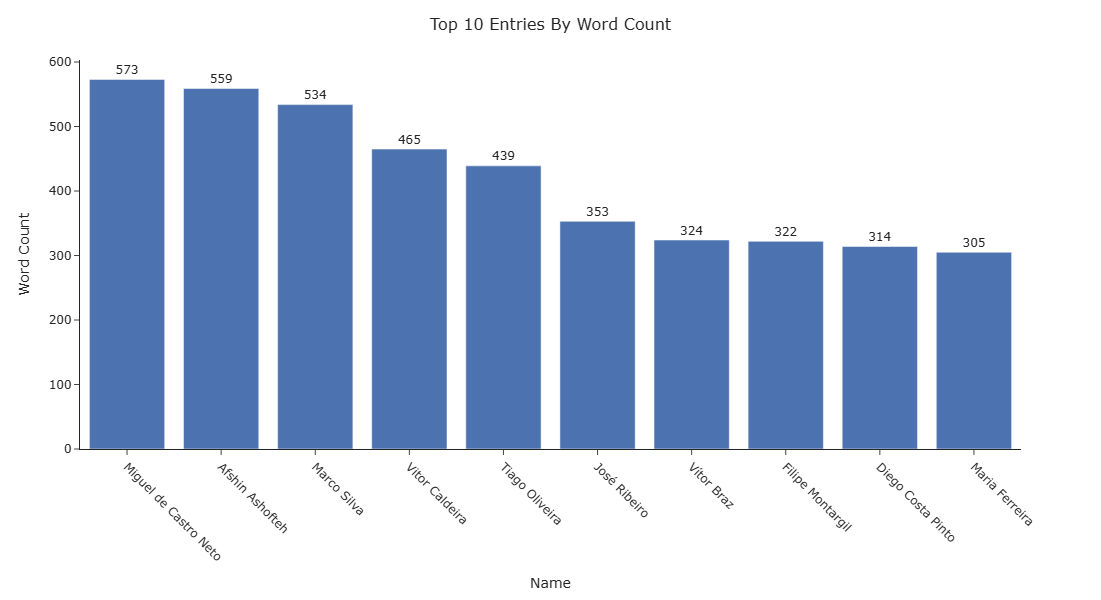

In [244]:
# Plotting our findings 

# Creating the bar plot
fig = px.bar(
    top_10_wc, 
    x='Name',  
    y='Word_Count', 
    text='Word_Count', 
    template='seaborn'
)

# Update layout for better readability
fig.update_layout(
    xaxis_title='Name',
    yaxis_title='Word Count',
    title={
        'text': "Top 10 Entries By Word Count", 
        'x': 0.5,  
    },
    title_font_size=16,
    xaxis_tickangle=45,
    width=1000,  
    height=600, 
    template='simple_white'
)

# Display the count on top of the bars
fig.update_traces(textposition='outside')
fig.show()

In [245]:
# Finding the teacher with the highest wordcount their name only
# Name only
hwcname = wcsort.iloc[0]['Name']
# Word count 
hwc = wcsort.iloc[0]['Word_Count'] 

In [246]:
print(f"The teacher with the most words in their biography was {hwcname}!")

The teacher with the most words in their biography was Miguel de Castro Neto!


<a class="anchor" id="">

### B) highest coursecount* (top 5) ?

</a>


In [248]:
# Finding staff with highest course count and sorting it to give the top 5
staff['Courses'] = staff['Courses'].str.split(', ')
staff['Course_Count'] = staff['Courses'].apply(lambda x: len(x))
ccsort = staff.sort_values(by='Course_Count', ascending=False)
top_5_cc = ccsort.head(5)

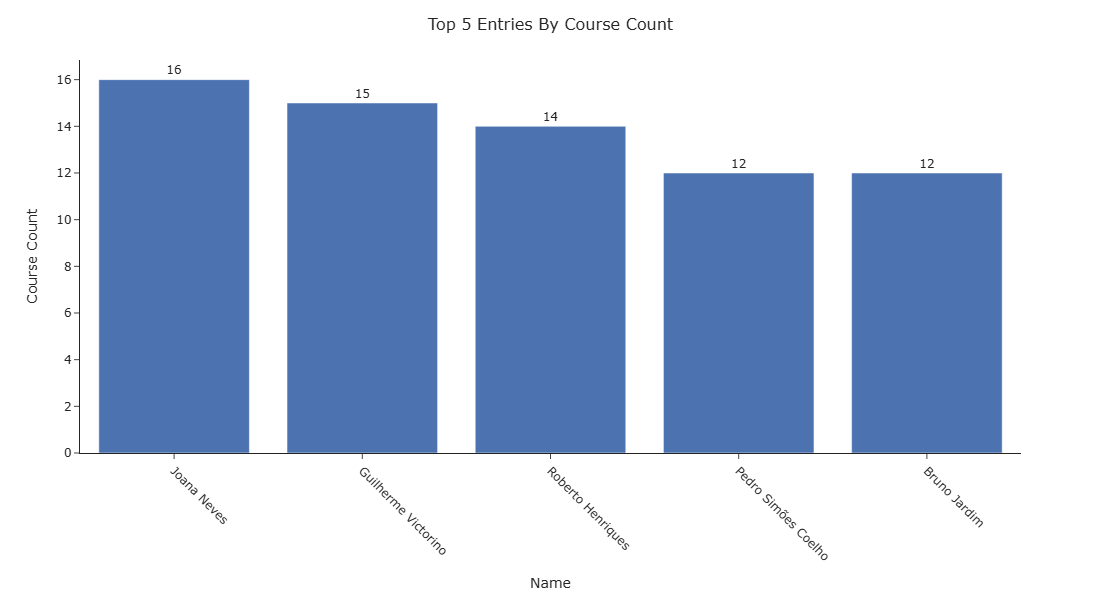

In [249]:
# Plotting our findings 

# Creating the bar plot
fig = px.bar(
    top_5_cc, 
    x='Name',  
    y='Course_Count', 
    text='Course_Count', 
    template='seaborn'
)

# Update layout for better readability
fig.update_layout(
    xaxis_title='Name',
    yaxis_title='Course Count',
    title={
        'text': "Top 5 Entries By Course Count", 
        'x': 0.5,  
    },
    title_font_size=16,
    xaxis_tickangle=45,
    width=1000,  
    height=600, 
    template='simple_white'
)

# Display the count on top of the bars
fig.update_traces(textposition='outside')
fig.show()

<a class="anchor" id="">

### C) most publications (top 10) ?
</a>


In [251]:
# Finding staff with highest publication count and sorting it to give us the top 10
pc = staff.sort_values(by='Publications', ascending=False)
top_10_p = pc.head(10)

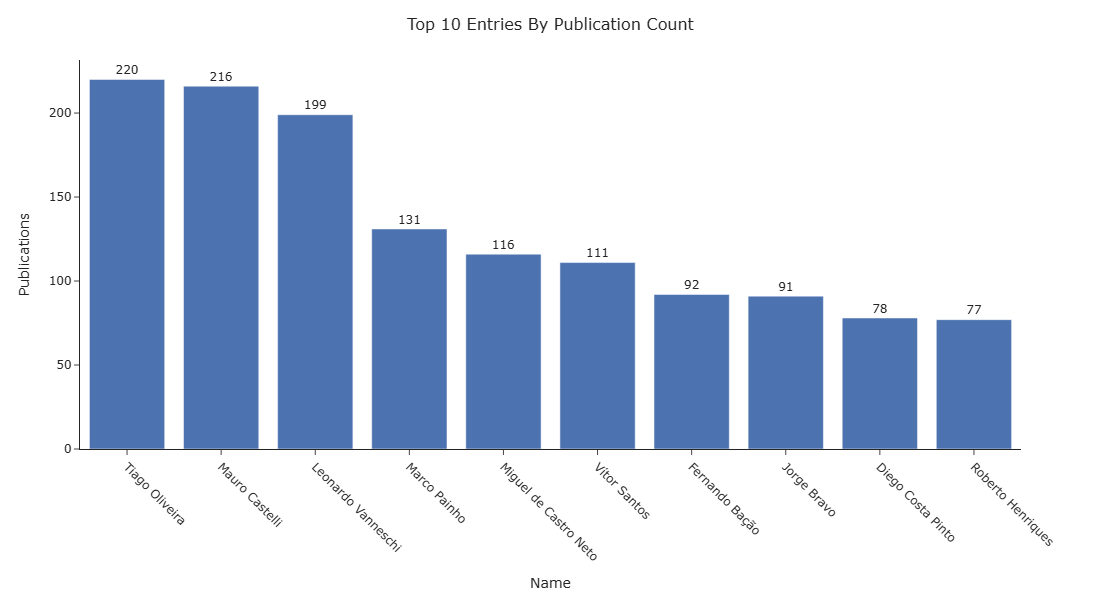

In [252]:
# Plotting our findings 

# Creating the bar plot
fig = px.bar(
    top_10_p, 
    x='Name',  
    y='Publications', 
    text='Publications', 
    template='seaborn'
)

# Update layout for better readability
fig.update_layout(
    xaxis_title='Name',
    yaxis_title='Publications',
    title={
        'text': "Top 10 Entries By Publication Count", 
        'x': 0.5,  
    },
    title_font_size=16,
    xaxis_tickangle=45,
    width=1000,  
    height=600, 
    template='simple_white'
)

# Display the count on top of the bars
fig.update_traces(textposition='outside')
fig.show()

<a class="anchor" id="">

# Question 3

</a>

<a class="anchor" id="">

### A) How are the wordcount, coursecount and publications distributed and related?

</a>


#### Distributions

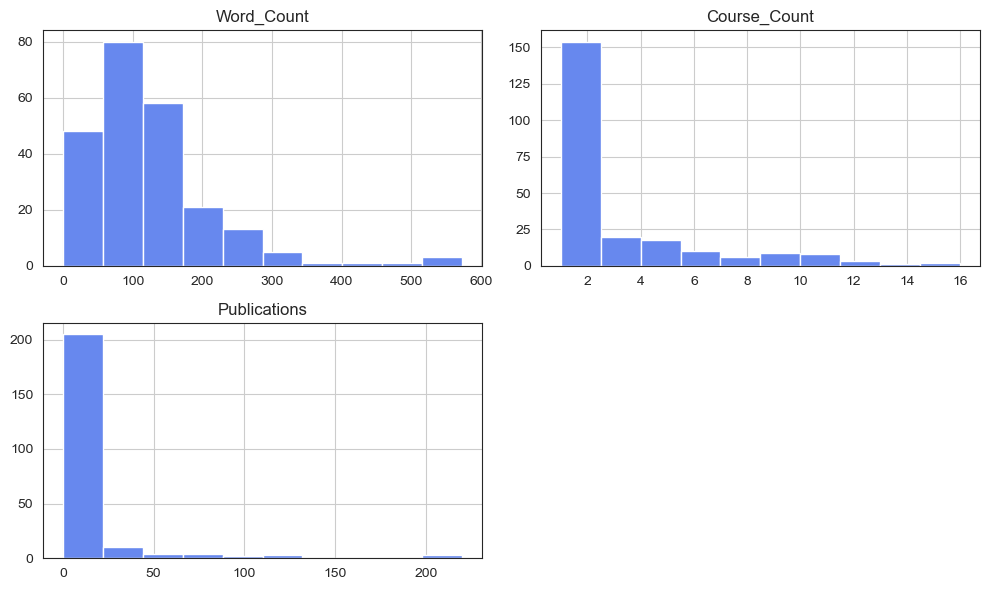

In [256]:
# Histograms showing the distributions of each catagory
staff[['Word_Count', 'Course_Count', 'Publications']].hist(bins=10, figsize=(10, 6))
plt.tight_layout()
plt.show()

#### Correlations

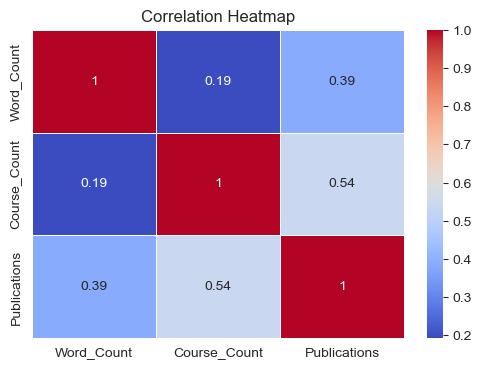

In [258]:
# Correlation heatmap to show correlation of each catagory 
correlation_matrix = staff[['Word_Count', 'Course_Count', 'Publications']].corr()
plt.figure(figsize=(6, 4))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

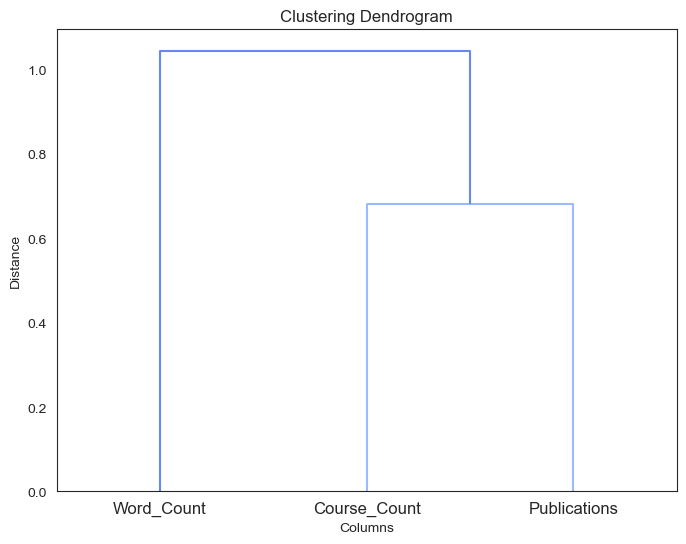

In [259]:
# Clustering dendrogram to further see correlation
x = linkage(correlation_matrix, 'average')
plt.figure(figsize=(8, 6))
dendrogram(x, labels=['Word_Count', 'Course_Count', 'Publications'])
plt.title('Clustering Dendrogram')
plt.xlabel('Columns')
plt.ylabel('Distance')
plt.show()

### Insights
- We see that the course count and is the most correlated to the publication count 

- Both of them give correlation scores that suggest they could be useful for predicting publication count 

<a class="anchor" id="">

### B) Are there differences in those variables for different types of teachers

</a>


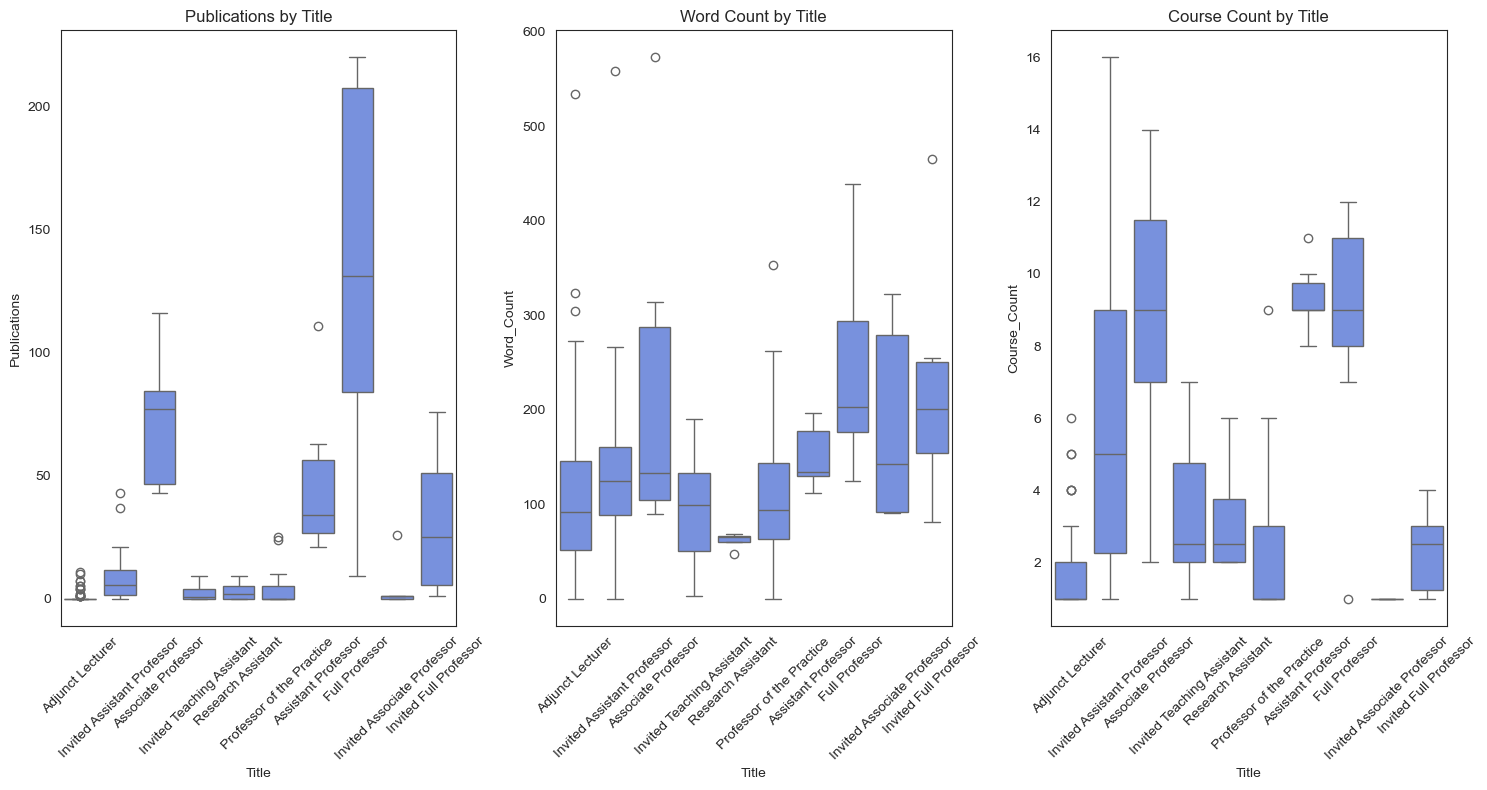

In [262]:
# Showing box plots for each target based on the teacher type 
plt.figure(figsize=(15, 8))

# Publications
plt.subplot(1, 3, 1)
sns.boxplot(data=staff, x='Title', y='Publications')
plt.title('Publications by Title')
plt.xticks(rotation=45)

# Word Counts
plt.subplot(1, 3, 2)
sns.boxplot(data=staff, x='Title', y='Word_Count')
plt.title('Word Count by Title')
plt.xticks(rotation=45)

# Course Counts
plt.subplot(1, 3, 3)
sns.boxplot(data=staff, x='Title', y='Course_Count')
plt.title('Course Count by Title')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

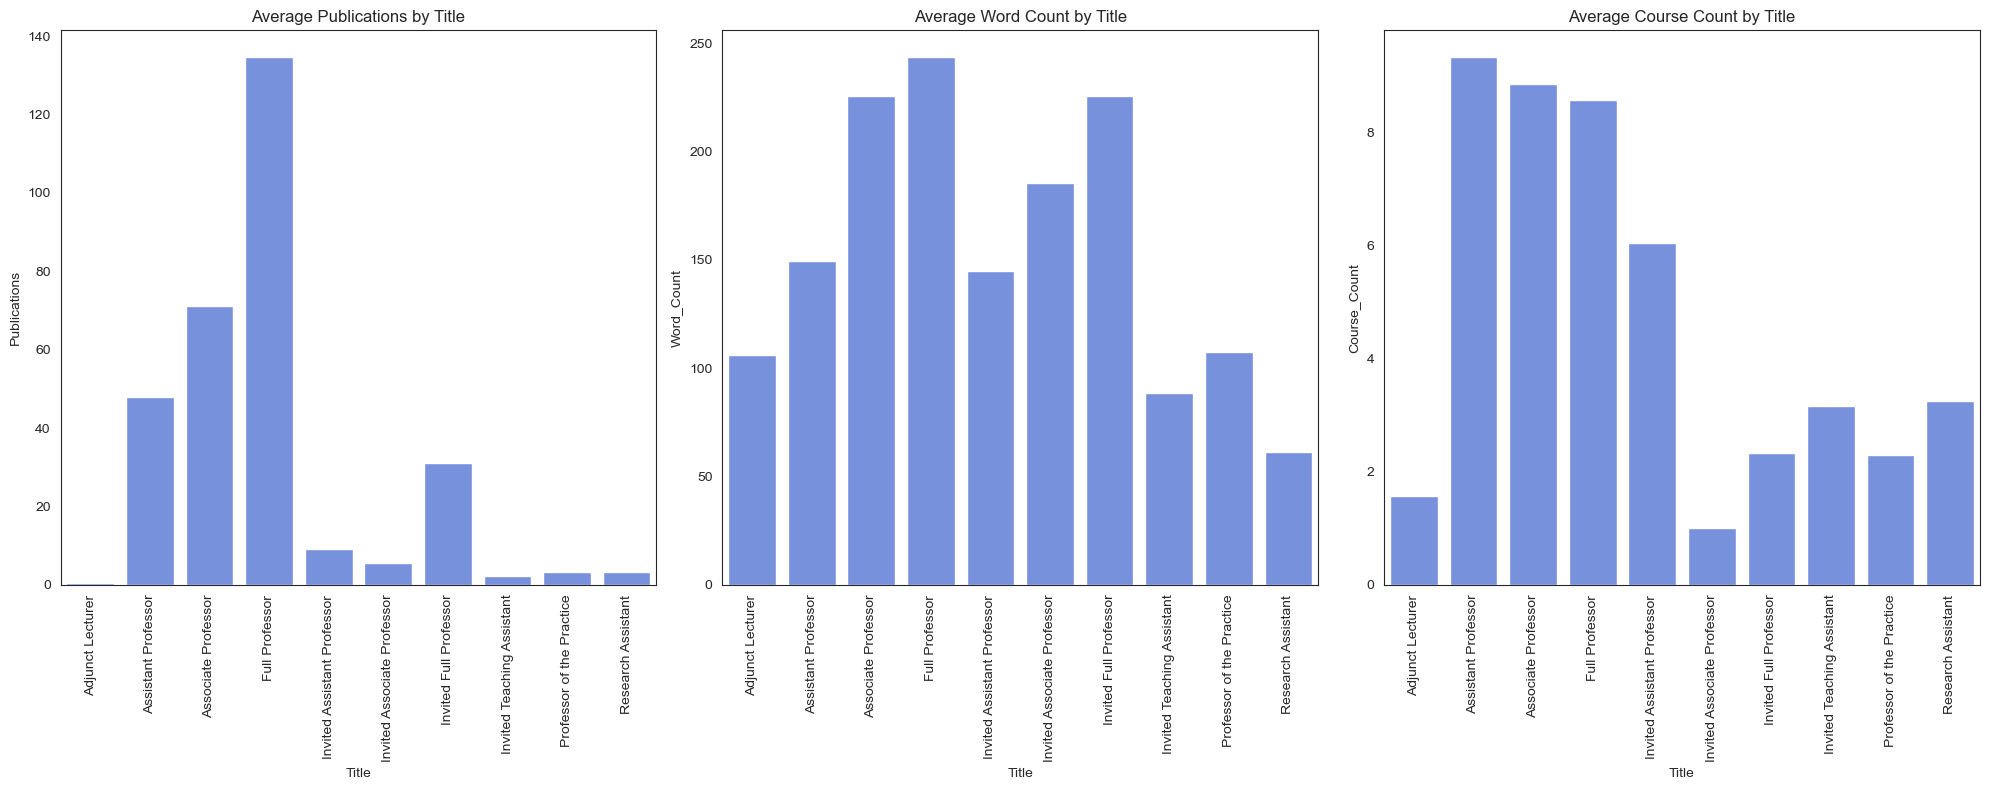

In [263]:
# Bar graphs for the average of each title 

# Means for each Title
means = staff.groupby('Title')[['Publications', 'Word_Count', 'Course_Count']].mean().reset_index()

plt.figure(figsize=(20, 8))

# Publications
plt.subplot(1, 3, 1)
sns.barplot(x='Title', y='Publications', data=means)
plt.title('Average Publications by Title')
plt.xticks(rotation=90)

# Word Counts
plt.subplot(1, 3, 2)
sns.barplot(x='Title', y='Word_Count', data=means)
plt.title('Average Word Count by Title')
plt.xticks(rotation=90)

# Course Counts
plt.subplot(1, 3, 3)
sns.barplot(x='Title', y='Course_Count', data=means)
plt.title('Average Course Count by Title')
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

### Insights
    
From the boxes
- Publications from the full professors have high variance
- There seem to be many outliers across the board
- Course count from the invited assistant professors has very high varience
  
From the bars
- Full professors have the highest average number of publications 
- Full professors have the highest average number of courses taught 
- Assistant professors have the highest average number of words in their biographies

<a class="anchor" id="">

# Question 4

</a>

<a class="anchor" id="">

### A) How many different courses (unique course names) are taught at NOVA IMS?

</a>


In [267]:
# Explode to get all the courses 
all_courses = staff['Courses'].explode()

# Get the unique course names
unique_courses = all_courses.unique()

# Count the number of unique courses
num_unique_courses = len(unique_courses)

print(f"The number of unique courses taught at NOVA IMS is: {num_unique_courses}")

The number of unique courses taught at NOVA IMS is: 278


<a class="anchor" id="">

### B) How many courses (unique course names) are taught by only one teacher?
</a>


In [269]:
# Explode the 'Courses' column to have one course per row
staff_expanded = staff.explode('Courses')

# Group by each course and count unique teachers
tpc = staff_expanded.groupby('Courses')['Name'].nunique() 

# Filter for courses with only one teacher
otpc = tpc[tpc == 1]

print(f"The amount of courses that are taught by only one teacher is {len(otpc)}")

The amount of courses that are taught by only one teacher is 140


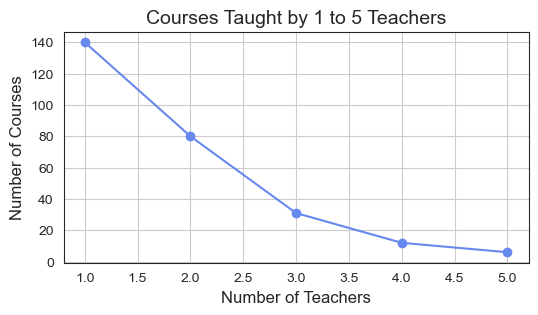

In [270]:
# Get teacher count for each course
teacher_distribution = tpc.value_counts().sort_index()

# Only use the top 5
teacher_distribution_top5 = teacher_distribution.head(5)

# Plot the data
plt.figure(figsize=(6, 3))
plt.plot(teacher_distribution_top5.index, teacher_distribution_top5.values, marker='o', linestyle='-')
plt.title('Courses Taught by 1 to 5 Teachers', fontsize=14)
plt.xlabel('Number of Teachers', fontsize=12)
plt.ylabel('Number of Courses', fontsize=12)
plt.grid(True)

plt.show()

<a class="anchor" id="">

### C) What's the probability of someone teaching 'Data Mining I' also teaching '‘Data Mining II'?



In [272]:
# Filter for teachers of "Data Mining I"
dm1 = staff[staff['Courses'].apply(lambda courses: 'Data Mining I' in courses)]

# Filter for teachers of "Data Mining I" (for venn diagram)
dm2 = staff[staff['Courses'].apply(lambda courses: 'Data Mining 2' in courses)]

# Filter for teachers of "Data Mining I" who also teach "Data Mining II"
dm12 = dm1[dm1['Courses'].apply(lambda courses: 'Data Mining II' in courses)]

# Calculate the probability
probability = len(dm12) / len(dm1) if len(dm1) > 0 else 0

print(f"The probability of someone teaching 'Data Mining I' also teaching 'Data Mining II' is: {probability:.2f}, or {probability * 100}%")

The probability of someone teaching 'Data Mining I' also teaching 'Data Mining II' is: 0.43, or 42.857142857142854%


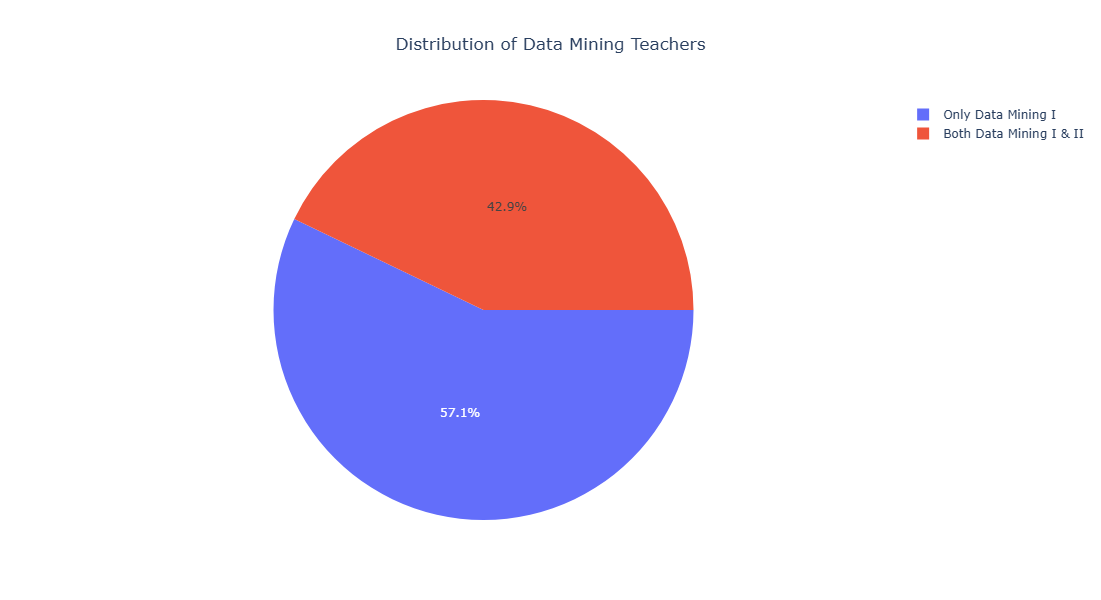

In [273]:
# Find teachers that only teach data mining 1, and those who teach both
teachers_only_dm1 = dm1[dm1['Courses'].apply(lambda x: 'Data Mining II' not in x)]['Name']  
teachers_both = dm12['Name'] 

# Prepare the labels and hover text to show the teachers in each catagory
labels = ['Only Data Mining I', 'Both Data Mining I & II']
sizes = [len(teachers_only_dm1), len(teachers_both)]
hover_text = [
    '<br>'.join(teachers_only_dm1), 
    '<br>'.join(teachers_both)      
]

# Create the pie chart
fig = go.Figure(data=[go.Pie(
    labels=labels,
    values=sizes,
    hoverinfo='label+text',  
    text=hover_text,         
    textinfo='percent',     
    rotation=90           
)])

fig.update_layout(
    title='Distribution of Data Mining Teachers',
    title_x=0.5,
    width=1000,  
    height=600 
)

# Show the interactive plot
fig.show()

<a class="anchor" id="" >

# Gain 3 additional insights of your choice
</a>


<a class="anchor" id="" >

# Predicting publication count from teacher profile

#### Using a Gradient Boost Regression model we want to be able to see what teachers are over / underperforming in terms of the number of publications they have.
  
#### We also plotted these findings on a scatter plot with a line of best fit, colouring the different performance evaluations to better see the distribution of all teachers 
</a>


### Feature encoding / selection

In [277]:
# Encode the catagorical columns

# Define encoders we are going to use
ohe = OneHotEncoder(sparse_output=False, drop='first')
mlb = MultiLabelBinarizer() 

# Apply encoding to Courses
courses_encoded = mlb.fit_transform(staff['Courses'])
courses_encoded_df = pd.DataFrame(courses_encoded, columns=mlb.classes_)

# Apply encoding to Titles in the original dataframe
encoded_titles = ohe.fit_transform(staff[['Title']])
encoded_titles_df = pd.DataFrame(encoded_titles, columns=ohe.get_feature_names_out(['Title']))

# Concatenate the one-hot encoded courses and titles into the original dataframe and drop the origionals 
staff_encoded = pd.concat([staff.reset_index(drop=True), courses_encoded_df.reset_index(drop=True), encoded_titles_df.reset_index(drop=True)], axis=1)
staff_encoded.drop(columns=['Courses', 'Title'], inplace=True)

In [278]:
# Finding common words used by teachers with publications to use as potential features

# Find teachers with publications and merge their biographies into one string and tokenize 
filtered_staff = staff[staff['Publications'] > 0]
all_biographies = ' '.join(filtered_staff['Biography'].tolist())
words = re.findall(r'\b\w+\b', all_biographies.lower())

# Load the list of stop words from the imported library to filter words that won't help
stop_words = set(nltk.corpus.stopwords.words('english'))

# Count occurrences of each word, get the most common words, and remove words that have < 5 occurrences
word_counts = Counter([word for word in words if word not in stop_words])
most_common_words = word_counts.most_common()
most_common_filtered = [(word, count) for word, count in most_common_words if count > 5]

# Display the top 20 common words
print(most_common_filtered[:20])

[('management', 199), ('information', 198), ('nova', 195), ('research', 137), ('university', 105), ('ims', 99), ('data', 92), ('degree', 83), ('systems', 83), ('statistics', 71), ('science', 67), ('international', 65), ('portugal', 60), ('master', 59), ('business', 58), ('school', 58), ('also', 56), ('professor', 55), ('de', 53), ('european', 52)]


In [279]:
# Use the words we think could be useful as features 

# List of selected words to check in the "Biography" column
keywords = ['PHD', "MASTER'S", 'RESEARCH', 'AUTHOR', 'DEGREE', 'RESEARCHER', "MASTER", "PROJECTS", "SOON"]

# Add a new column for each keyword, setting to 1 if the word is found, else 0
for word in keywords:
    staff_encoded[word] = staff_encoded['Biography'].str.contains(word, case=False).astype(int)

# Check that it worked 
staff_encoded.head()

,Name,Publications,Biography,Word_Count,Course_Count,Statistical Treatment of Data,Acompanhamento de Dissertação/Trabalho de Projeto,Administrative Sources and Big Data,Adoption Models,Advanced Topics Geographic Information Science,...,Title_Research Assistant,PHD,MASTER'S,RESEARCH,AUTHOR,DEGREE,RESEARCHER,MASTER,PROJECTS,SOON
0,Afonso Malheiro,0,Bachelor's degree in Management (Catholic Univ...,76,1,0,0,0,0,0,...,0.0,0,0,0,0,1,0,0,0,0
1,Afshin Ashofteh,21,Afshin Ashofteh is a full-time University Prof...,559,9,0,0,0,0,0,...,0.0,0,1,1,0,1,1,1,1,0
2,Alexandra Variz,0,"Currently, I am working as a Digital Marketing...",224,1,0,0,0,0,0,...,0.0,0,1,0,0,1,0,1,0,0
3,Alexandre Guilherme Marques,0,Alexandre Marques is an assistant professor at...,75,1,0,0,0,0,0,...,0.0,0,0,1,0,0,0,0,1,0
4,Alexandre Neto,0,Bachelor's degree in Geographical Engineering ...,185,1,0,0,0,0,0,...,0.0,0,1,0,0,1,0,1,0,0


In [280]:
# Feature Scaling 
scaler = StandardScaler()
staff_encoded[['Word_Count']] = scaler.fit_transform(staff_encoded[['Word_Count']])

In [281]:
'''# Set up the model

# Use all columns as features unless they are listed 
features_to_exclude = ['Publications', 'Biography', 'Name']
feature_columns = [col for col in staff_encoded.columns if col not in features_to_exclude]

X = staff_encoded[feature_columns]
y = staff_encoded["Publications"]

# Split the data into 70% train 30% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialize model for tuning
model = GradientBoostingRegressor(random_state=42)

# Define the hyperparameters for the random search 
rs_params = {
    'n_estimators': randint(50, 200),  
    'learning_rate': [0.01, 0.05, 0.1, 0.2],  
    'max_depth': randint(3, 6),  
    'subsample': [0.7, 0.8, 0.9, 1.0],  
}

# Set up random search
rs = RandomizedSearchCV(estimator=model, param_distributions=rs_params, 
                        n_iter=50, cv=5, n_jobs=-1, verbose=1, random_state=42, scoring='neg_mean_squared_error')

# Fit random searchascii
rs.fit(X_train, y_train)

# Print the best parameters and best score from the random search 
print("Best parameters from RandomizedSearchCV: ", rs.best_params_)
print("Best cross-validation score from RandomizedSearchCV: ", rs.best_score_)'''

'# Set up the model\n\n# Use all columns as features unless they are listed \nfeatures_to_exclude = [\'Publications\', \'Biography\', \'Name\']\nfeature_columns = [col for col in staff_encoded.columns if col not in features_to_exclude]\n\nX = staff_encoded[feature_columns]\ny = staff_encoded["Publications"]\n\n# Split the data into 70% train 30% test\nX_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)\n\n# Initialize model for tuning\nmodel = GradientBoostingRegressor(random_state=42)\n\n# Define the hyperparameters for the random search \nrs_params = {\n    \'n_estimators\': randint(50, 200),  \n    \'learning_rate\': [0.01, 0.05, 0.1, 0.2],  \n    \'max_depth\': randint(3, 6),  \n    \'subsample\': [0.7, 0.8, 0.9, 1.0],  \n}\n\n# Set up random search\nrs = RandomizedSearchCV(estimator=model, param_distributions=rs_params, \n                        n_iter=50, cv=5, n_jobs=-1, verbose=1, random_state=42, scoring=\'neg_mean_squared_error\')\n\n# Fi

In [282]:
'''# Set up a grid search based on the results of the random search 
best_rs_params = rs.best_params_

# Define the hyperparameters for GridSearchCV based on the results from RandomizedSearchCV
gs_params = {
    'n_estimators': [best_rs_params['n_estimators'] - 50, best_rs_params['n_estimators'], best_rs_params['n_estimators'] + 50],
    'learning_rate': [best_rs_params['learning_rate'] - 0.05, best_rs_params['learning_rate'], best_rs_params['learning_rate'] + 0.05],
    'max_depth': [best_rs_params['max_depth'] - 1, best_rs_params['max_depth'], best_rs_params['max_depth'] + 1],
    'subsample': [best_rs_params['subsample'] - 0.1, best_rs_params['subsample'], best_rs_params['subsample'] + 0.1]
}

# Set up GridSearchCV with a refined search space based on RandomizedSearchCV results
gs = GridSearchCV(estimator=model, param_grid=gs_params, cv=5, n_jobs=-1, verbose=1, scoring='neg_mean_squared_error')

# Fit GridSearchCV
gs.fit(X_train, y_train)

# Print the best parameters and best score from GridSearchCV
print("Best parameters from GridSearchCV: ", gs.best_params_)
print("Best cross-validation score from GridSearchCV: ", gs.best_score_)

# Evaluate the best model on the test set
test_score = best_model.score(X_test, y_test)
print(f"Test score of the best model: {test_score}")'''

'# Set up a grid search based on the results of the random search \nbest_rs_params = rs.best_params_\n\n# Define the hyperparameters for GridSearchCV based on the results from RandomizedSearchCV\ngs_params = {\n    \'n_estimators\': [best_rs_params[\'n_estimators\'] - 50, best_rs_params[\'n_estimators\'], best_rs_params[\'n_estimators\'] + 50],\n    \'learning_rate\': [best_rs_params[\'learning_rate\'] - 0.05, best_rs_params[\'learning_rate\'], best_rs_params[\'learning_rate\'] + 0.05],\n    \'max_depth\': [best_rs_params[\'max_depth\'] - 1, best_rs_params[\'max_depth\'], best_rs_params[\'max_depth\'] + 1],\n    \'subsample\': [best_rs_params[\'subsample\'] - 0.1, best_rs_params[\'subsample\'], best_rs_params[\'subsample\'] + 0.1]\n}\n\n# Set up GridSearchCV with a refined search space based on RandomizedSearchCV results\ngs = GridSearchCV(estimator=model, param_grid=gs_params, cv=5, n_jobs=-1, verbose=1, scoring=\'neg_mean_squared_error\')\n\n# Fit GridSearchCV\ngs.fit(X_train, y_trai

### Model implementation 

In [284]:
# Set up the model

# Use all columns as features except the ones listed 
features_to_exclude = ['Publications', 'Biography', 'Name']
feature_columns = [col for col in staff_encoded.columns if col not in features_to_exclude]

X = staff_encoded[feature_columns]
y = staff_encoded['Publications']

# split the data into 70% train 30% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialize and fit the model
model = GradientBoostingRegressor(
    random_state=42,
    learning_rate=0.1,
    max_depth=4,
    n_estimators=181,
    subsample=0.7
)

model.fit(X_train, y_train)

GradientBoostingRegressor(max_depth=4, n_estimators=181, random_state=42,
                          subsample=0.7)

### Model Evaluation

In [286]:
y_pred = model.predict(X_test) # Predict on the test set 
y_pred = np.round(y_pred).astype(int)

mse = mean_squared_error(y_test, y_pred) # Mean Squared Error will give us a sense of the average error in the predictions.
r2 = r2_score(y_test, y_pred) # R-squared will give us an idea of how well the model fits the data. The closer to 1, the better the model explains the variance in the data.

print(f"Mean Squared Error: {mse}")
print(f"R-Squared: {r2}")

Mean Squared Error: 97.52857142857142
R-Squared: 0.535144999080776


### Feature importances

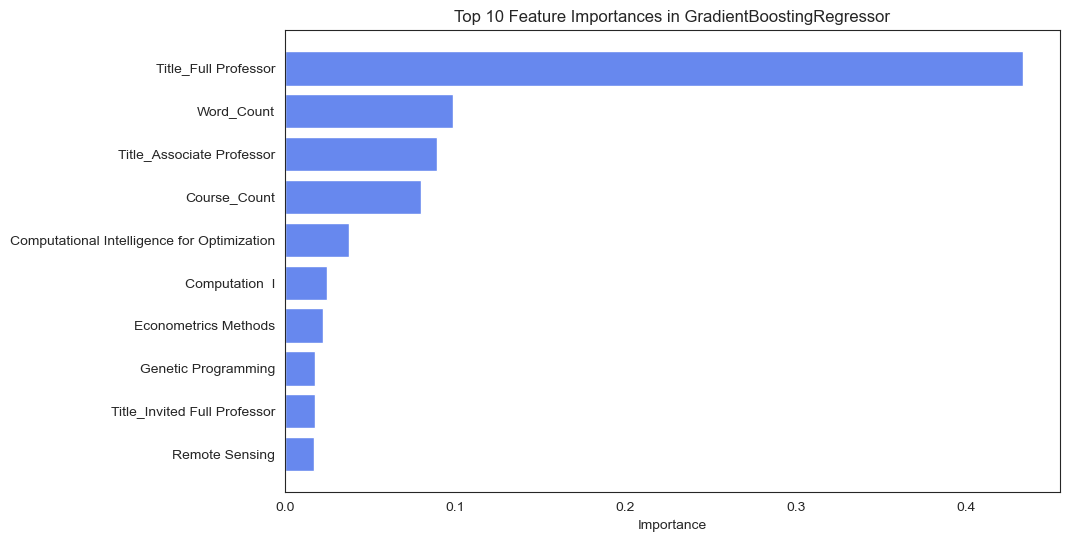

In [288]:
# Get the feature importances from the model
feature_importances = model.feature_importances_

# Create a DataFrame for easy plotting
feature_importance_df = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': feature_importances
})

# Sort the DataFrame by feature importance in descending order
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Select the top 10 features
top_10_features = feature_importance_df.head(10)

# Plotting the top 10 feature importances
plt.figure(figsize=(10, 6))
plt.barh(top_10_features['Feature'], top_10_features['Importance'])
plt.xlabel('Importance')
plt.title('Top 10 Feature Importances in GradientBoostingRegressor')
plt.gca().invert_yaxis()  
plt.show()


### Finding / Classifying Over / Under Achievers 

In [290]:
# Predict publications for the original dataset
X_original = staff_encoded[feature_columns]  
staff_encoded['Predicted Publications'] = model.predict(X_original)
staff_encoded['Predicted Publications'] = staff_encoded['Predicted Publications'].clip(lower=0)
staff_encoded['Predicted Publications'] = np.round(staff_encoded['Predicted Publications']).astype(int)

# Calculate the difference between actual and predicted values
staff_encoded['Difference'] = staff_encoded['Publications'] - staff_encoded['Predicted Publications']

# Categorize teachers based on the difference
def categorize_performance(diff):
    if diff > 0:
        return 'Over Achiever'
    elif diff < 0:
        return 'Under Achiever'
    else:
        return 'Meets Expectations'

staff_encoded['Performance Status'] = staff_encoded['Difference'].apply(categorize_performance)

# Summary of performance
performance_summary = staff_encoded[['Name', 'Publications', 'Predicted Publications', 'Difference', 'Performance Status']]

In [291]:
top_over = performance_summary.sort_values(by='Difference', ascending=False)
top_under = performance_summary.sort_values(by='Difference', ascending=True) 

In [292]:
# Top 3 Over-Achievers 
top_over.head(3)

,Name,Publications,Predicted Publications,Difference,Performance Status
226,Vítor Santos,111,52,59,Over Achiever
215,Tiago Humberto Oliveira,11,3,8,Over Achiever
124,Manuel Cabugueira,8,0,8,Over Achiever


In [293]:
# Bottom 3 Under-Achievers
top_under.head(3)

,Name,Publications,Predicted Publications,Difference,Performance Status
60,Gonçalo Baptista,5,32,-27,Under Achiever
95,Jorge Carrola Rodrigues,10,36,-26,Under Achiever
75,Inês Magessi,0,26,-26,Under Achiever


In [361]:
# Comparison of predictions vs actual publications 
performance_summary.describe()

,Publications,Predicted Publications,Difference
count,231.000000,231.000000,231.000000
mean,10.489177,10.982684,-0.493506
std,30.882366,30.163751,5.501676
min,0.000000,0.000000,-27.000000
25%,0.000000,0.000000,-1.000000
50%,0.000000,1.000000,0.000000
75%,5.000000,5.500000,0.000000
max,220.000000,220.000000,59.000000


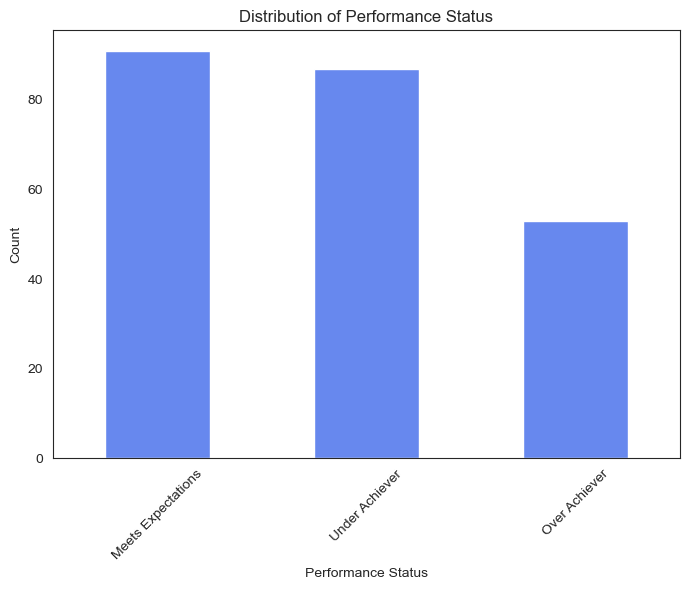

In [295]:
# Show the distribution of catagories 
plt.figure(figsize=(7, 6))
performance_summary['Performance Status'].value_counts().plot(kind='bar')
plt.title('Distribution of Performance Status')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Result Visualization 

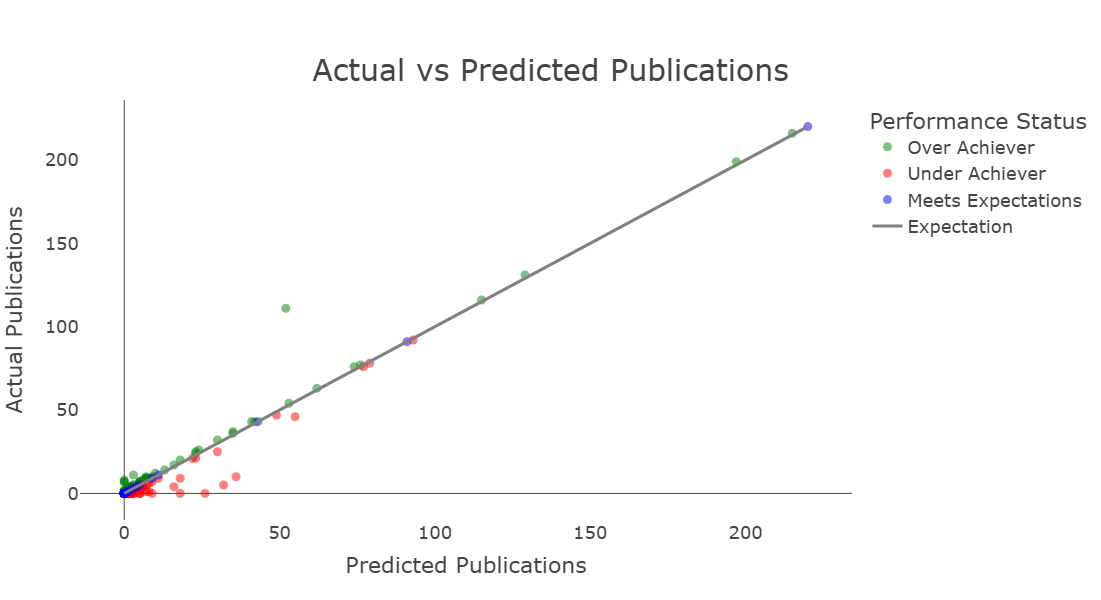

In [297]:
fig = go.Figure()

# Classifications 
over_achievers = staff_encoded[staff_encoded['Performance Status'] == 'Over Achiever']
under_achievers = staff_encoded[staff_encoded['Performance Status'] == 'Under Achiever']
meets_expectations = staff_encoded[staff_encoded['Performance Status'] == 'Meets Expectations']

# Scatter plot for Over Achievers
fig.add_trace(go.Scatter(
    x=over_achievers['Predicted Publications'],
    y=over_achievers['Publications'],
    mode='markers',
    name='Over Achiever',
    marker=dict(color='green', opacity=0.5),
    hovertext = np.where(
    over_achievers.groupby(['Predicted Publications', 'Publications'])['Name'].transform('count') > 1,
    over_achievers['Name'] + ' and ' + (over_achievers.groupby(['Predicted Publications', 'Publications'])['Name'].transform('count') - 1).astype(str) + ' others',
    over_achievers['Name']),   
    hoverinfo='text+x+y'
))

# Scatter plot for Under Achievers
fig.add_trace(go.Scatter(
    x=under_achievers['Predicted Publications'],
    y=under_achievers['Publications'],
    mode='markers',
    name='Under Achiever',
    marker=dict(color='red', opacity=0.5),
    hovertext = np.where(
    under_achievers.groupby(['Predicted Publications', 'Publications'])['Name'].transform('count') > 1,
    under_achievers['Name'] + ' and ' + (under_achievers.groupby(['Predicted Publications', 'Publications'])['Name'].transform('count') - 1).astype(str) + " others",
    under_achievers['Name']),   
    hoverinfo='text+x+y'
))

# Scatter plot for Meets Expectations
fig.add_trace(go.Scatter(
    x=meets_expectations['Predicted Publications'],
    y=meets_expectations['Publications'],
    mode='markers',
    name='Meets Expectations',
    marker=dict(color='blue', opacity=0.5),
    hovertext = np.where(
    meets_expectations.groupby(['Predicted Publications', 'Publications'])['Name'].transform('count') > 1,
    meets_expectations['Name'] + ' and ' + (meets_expectations.groupby(['Predicted Publications', 'Publications'])['Name'].transform('count') - 1).astype(str) + " others",
    meets_expectations['Name']),   
    hoverinfo='text+x+y'
))

# Reference line for perfect prediction
x_vals = np.linspace(min(staff_encoded['Predicted Publications']), max(staff_encoded['Predicted Publications']), 100)
fig.add_trace(go.Scatter(
    x=x_vals,
    y=x_vals,
    mode='lines',
    name='Expectation',
    line=dict(color='grey')
))

# Update layout
fig.update_layout(
    title={'text': 'Actual vs Predicted Publications',
           'x': 0.5,
           'y': 0.9,
           'xanchor': 'center',
           'font': {'size': 30}
          },
    xaxis_title='Predicted Publications',
    yaxis_title='Actual Publications',
    legend_title_text='Performance Status',
    width=1000,
    height=600,
    xaxis=dict(showgrid=False),  
    yaxis=dict(showgrid=False),
    template='presentation'
)

# Show plot
fig.show()

<a class="anchor" id="" >

# New course recommendation 

</a>


In [299]:
# Select only the course columns for similarity calculation
unique_courses = courses_encoded_df.columns.tolist()
course_df = staff_encoded[unique_courses]

# Calculate similarity matrix between teachers
similarity_matrix = cosine_similarity(course_df)
similarity_df = pd.DataFrame(similarity_matrix, index=staff_encoded.index, columns=staff_encoded.index)

# Function to recommend courses with course popularity
def recommend_courses(teacher_id, n_recommendations=3):
    similar_teachers = similarity_df[teacher_id].sort_values(ascending=False).index[1:]  # Exclude self
    current_courses = set(course_df.columns[course_df.loc[teacher_id] == 1])

# Gather recommendations from similar teachers
    recommendations = set()
    for similar_teacher in similar_teachers:
        similar_teacher_courses = set(course_df.columns[course_df.loc[similar_teacher] == 1])
        new_courses = similar_teacher_courses.difference(current_courses)
        recommendations.update(new_courses)

# Break if enough recommendations have been collected
        if len(recommendations) >= n_recommendations:
            break

# Rank recommendations by course popularity (how many teachers teach the course)
    ranked_recommendations = sorted(recommendations, key=lambda course: course_df[course].sum(), reverse=True)
    return ranked_recommendations[:n_recommendations]

In [300]:
# Example usage
teacher_id = 5  # Replace with the ID of the teacher for whom you want recommendations
n_recommendations = 3 # Number of desired recommendations
recommended_courses = recommend_courses(teacher_id, n_recommendations)
print(f'Recommended courses for {staff_encoded['Name'][teacher_id]}: {recommended_courses}')

Recommended courses for Américo Rio: ['Data Management and Storage', 'Armazenamento e Recuperação de Dados', 'UX Research']


<a class="anchor" id="" >

# Biography Word Cloud

</a>


In [302]:
# Determine the median publication and course counts
course_median = staff['Course_Count'].median()


# Split into high and low groups

# Publications 
high_pub_staff = staff[staff['Publications'] >= 1]
low_pub_staff = staff[staff['Publications'] < 1]

# Courses
high_course_staff = staff[staff['Course_Count'] >= course_median] 
low_course_staff = staff[staff['Course_Count'] < course_median]

In [303]:
# Add our own custom stop words and use the ones imported earlier 
custom_stop_words = ['degree', 'nova', 'ims', 'information', 'management', 'university', 'systems', 'science', 'data', 'de', 'also', 'business', 'since', 'currently']
stop_words.update(custom_stop_words)

# Find word counts for each word
def get_word_counts(staff):
    bio_text = ' '.join(staff['Biography'])
    words = [word.lower() for word in re.findall(r'\w+', bio_text)]
    word_counts = Counter(word for word in words if word not in stop_words)
    return word_counts

# Split into the different catagories so we can look for patterns 
high_pub_counts = get_word_counts(high_pub_staff)
low_pub_counts = get_word_counts(low_pub_staff)
high_course_counts = get_word_counts(high_course_staff)
low_course_counts = get_word_counts(low_course_staff)

In [304]:
# Function to get the top 5 words for each catagory 
def top_words(word_counts, n=5):
    most_common = word_counts.most_common(n)
    for word, count in most_common:
        print(f"{word}: {count}")

print('High Publications:')
top_words(high_pub_counts)
print('\nLow Publications:')
top_words(low_pub_counts)

print('\nHigh Courses:')
top_words(high_course_counts) 
print('\nLow Courses:')
top_words(low_course_counts)

High Publications:
research: 137
statistics: 71
international: 65
portugal: 60
master: 59

Low Publications:
marketing: 73
master: 71
digital: 57
holds: 57
lisbon: 54

High Courses:
research: 132
master: 77
school: 64
statistics: 61
holds: 59

Low Courses:
digital: 58
economics: 58
marketing: 55
international: 55
research: 55


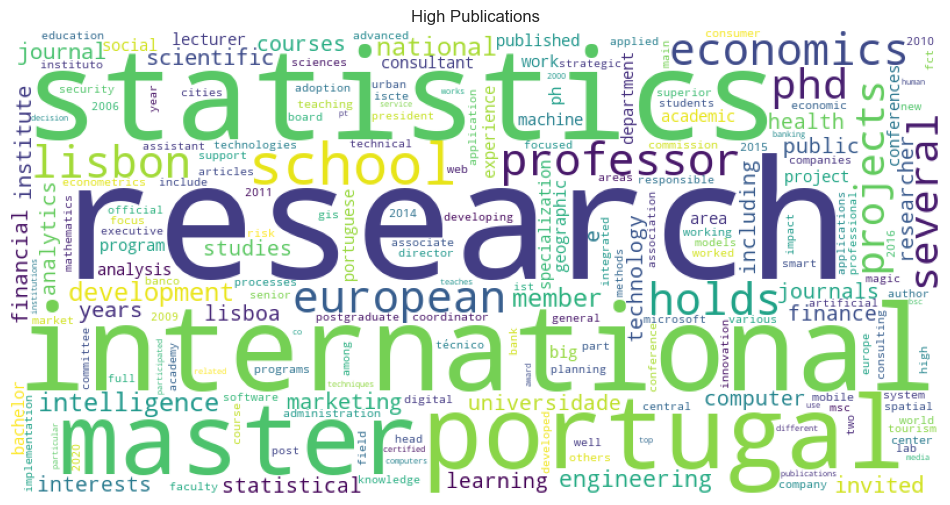

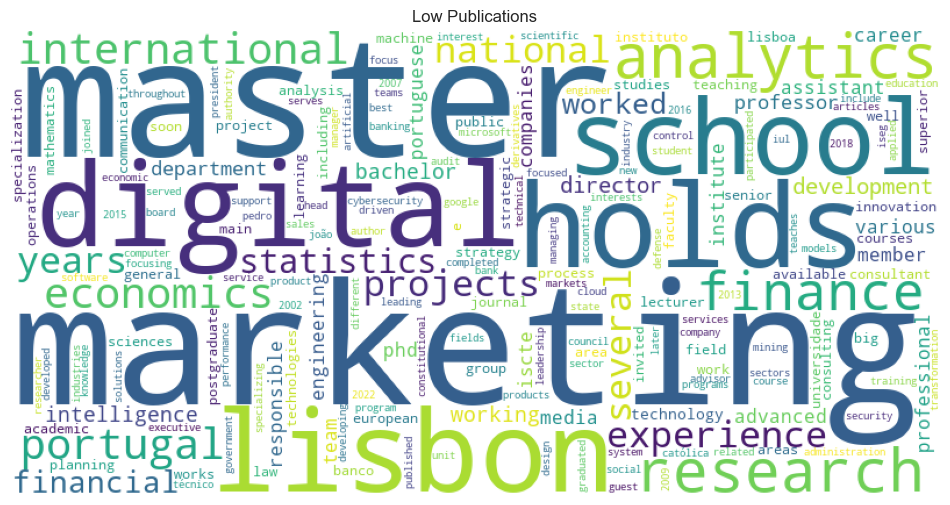

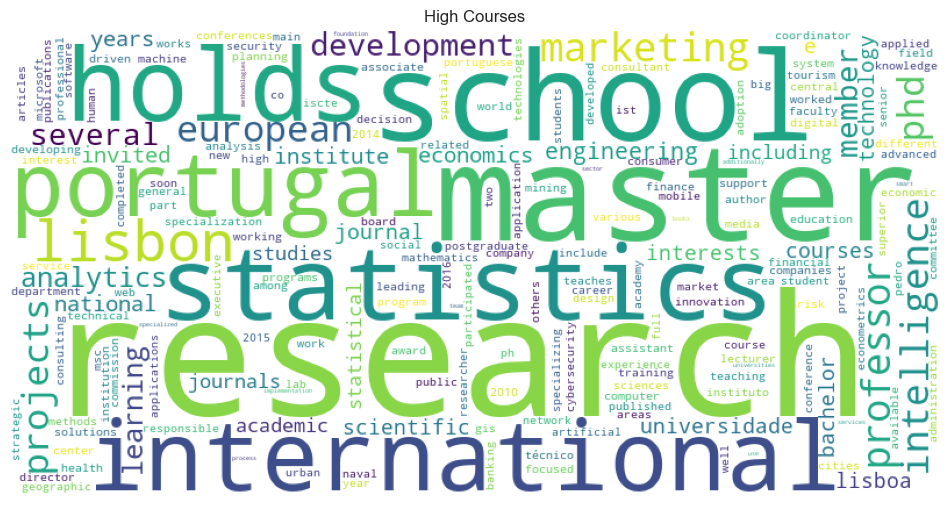

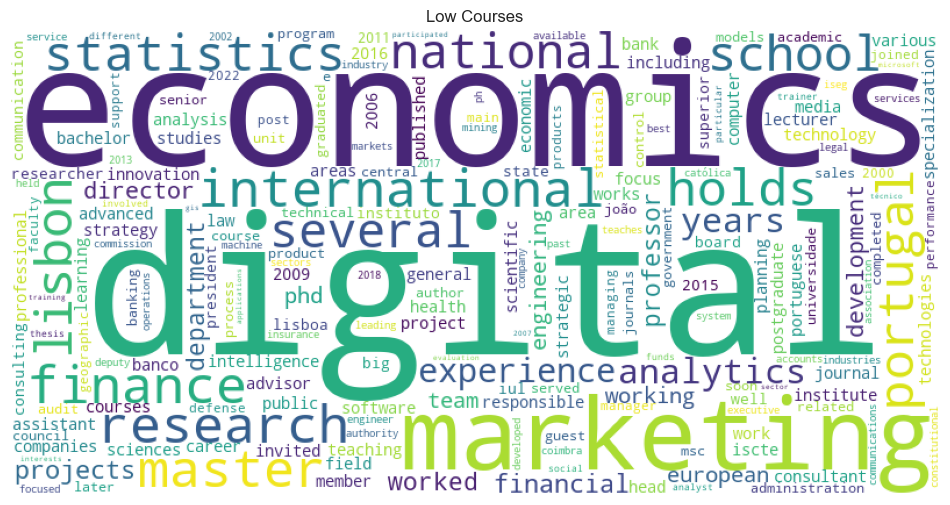

In [305]:
# Function to make a wordcloud for each catagory
def create_wordcloud(word_counts, title):
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word_counts)
    plt.figure(figsize=(12,8))
    plt.imshow(wordcloud)
    plt.title(title)
    plt.axis('off')
    plt.show()

create_wordcloud(high_pub_counts, 'High Publications')
create_wordcloud(low_pub_counts, 'Low Publications')
create_wordcloud(high_course_counts, 'High Courses')
create_wordcloud(low_course_counts, 'Low Courses')